In [11]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import warnings

from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from keras.preprocessing.image import ImageDataGenerator
from keras import applications
from keras.models import Sequential, load_model, Model
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout
from keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau, TensorBoard
from keras import optimizers, losses, activations, models
from keras.layers import Convolution2D, Dense, Input, Flatten, Dropout, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Concatenate

In [12]:
# Settings
warnings.filterwarnings('ignore')
BATCH_SIZE = 64
IMAGE_SIZE = 380

In [13]:
# Data generator with data augmentation for the training set
train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Data generator without data augmentation for the validation and test sets
test_generator = ImageDataGenerator(rescale=1./255)

In [14]:
# Load data
download_dir = Path("./animals/")

train_data_dir = download_dir/'train'
valid_data_dir = download_dir/'validation'
test_data_dir = download_dir/'test'


traingen = train_generator.flow_from_directory(train_data_dir,
                                               target_size=(IMAGE_SIZE, IMAGE_SIZE),
                                               class_mode='categorical',
                                               subset='training',
                                               color_mode="rgb",
                                               batch_size=BATCH_SIZE, 
                                               shuffle=True,
                                               seed=42)

validgen = test_generator.flow_from_directory(valid_data_dir,
                                              target_size=(IMAGE_SIZE, IMAGE_SIZE),
                                              class_mode='categorical',
                                              color_mode="rgb",
                                              batch_size=BATCH_SIZE)

testgen = test_generator.flow_from_directory(test_data_dir,
                                              target_size=(IMAGE_SIZE, IMAGE_SIZE),
                                              class_mode=None,
                                              color_mode="rgb",
                                              batch_size=1,
                                              shuffle=False)

Found 14308 images belonging to 50 classes.
Found 500 images belonging to 50 classes.
Found 50 images belonging to 50 classes.


In [15]:
x,y = next(traingen)
x.shape

(64, 380, 380, 3)

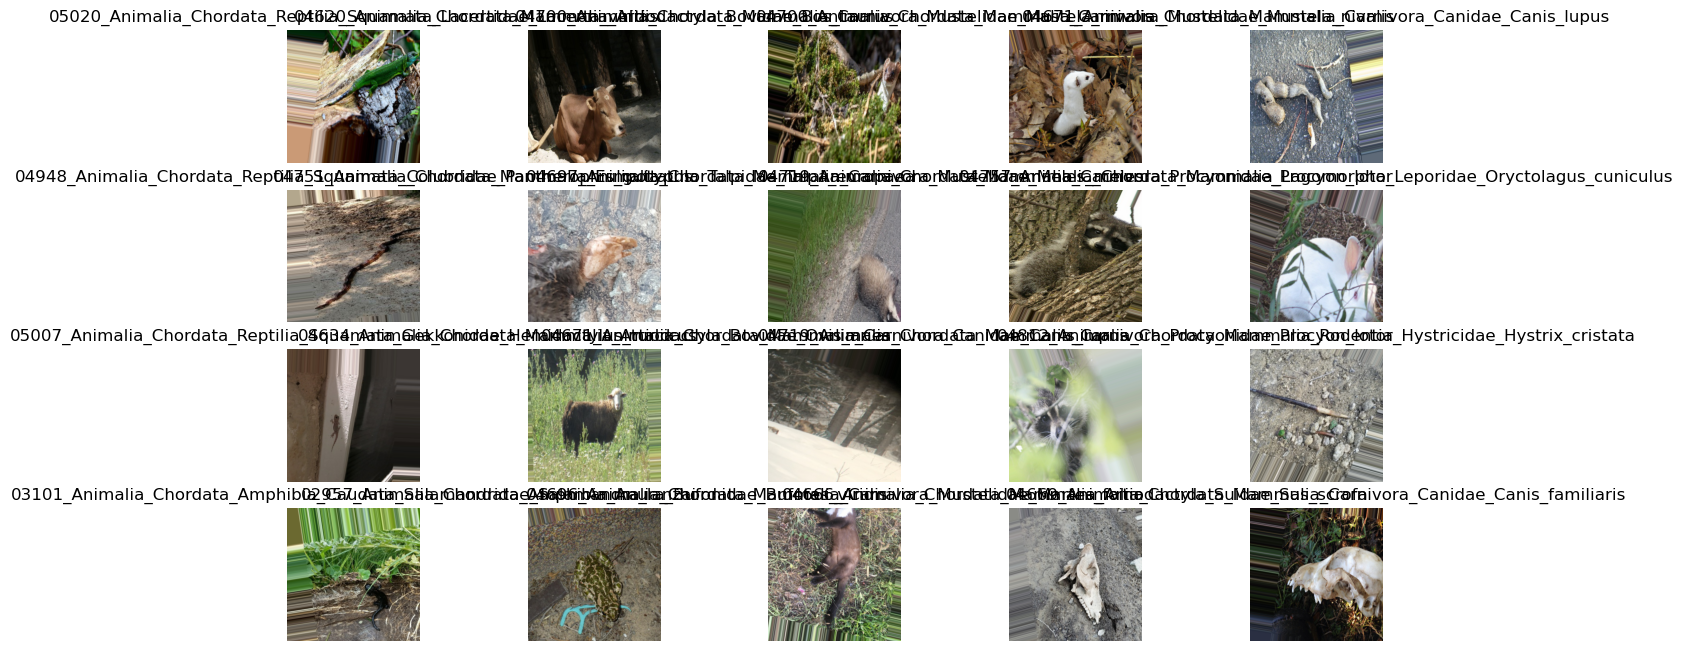

In [16]:
a = traingen.class_indices
class_names = list(a.keys())

# Plot examples

def plot_images(img, labels):
    plt.figure(figsize=[15, 10])
    for i in range(20):
        plt.subplot(5, 5, i+1)
        plt.imshow(img[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')

plot_images(x,y)

In [17]:
# Params
n_classes = 50
n_steps = traingen.samples // BATCH_SIZE
n_val_steps = validgen.samples // BATCH_SIZE
n_epochs = 100

In [8]:
# Build Model InceptionV3
base_model = applications.InceptionV3(weights='imagenet', 
                                include_top=False, 
                                input_shape=(IMAGE_SIZE, IMAGE_SIZE,3))
base_model.trainable = False

add_model = Sequential()
add_model.add(base_model)
add_model.add(GlobalAveragePooling2D())
add_model.add(Dropout(0.5))
add_model.add(Dense(n_classes, activation='softmax'))

model = add_model

# Use a smaller learning rate for fine-tuning
optimizer = optimizers.Adam(lr=1e-4)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.summary()

2023-04-25 18:32:38.731198: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2023-04-25 18:32:38.957847: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2023-04-25 18:32:38.958093: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2023-04-25 18:32:38.959165: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2023-04-25 18:32:38.959396: I tensorflow/compile

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 10, 10, 2048)      21802784  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 50)                102450    
                                                                 
Total params: 21,905,234
Trainable params: 102,450
Non-trainable params: 21,802,784
_________________________________________________________________


In [9]:
# Callbacks
early_stopping = EarlyStopping(patience=15, restore_best_weights=True)

# Save the best model during training
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max')

# Reduce learning rate when the validation loss plateaus
reduce_lr_on_plateau = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, verbose=1, mode='min')

# fit model
history = model.fit(traingen,
                    steps_per_epoch=n_steps,
                    validation_data=validgen,
                    validation_steps=n_val_steps,
                    epochs=n_epochs,
                    callbacks=[early_stopping, model_checkpoint, reduce_lr_on_plateau])

Epoch 1/100


2023-04-25 18:32:44.712689: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2023-04-25 18:32:50.566262: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8801
2023-04-25 18:32:52.366433: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


223/223 [==============================] - ETA: 0s - loss: 3.8407 - accuracy: 0.0601

2023-04-25 18:38:52.974146: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


223/223 [==============================] - 374s 2s/step - loss: 3.8407 - accuracy: 0.0601 - val_loss: 3.4506 - val_accuracy: 0.2879 - lr: 1.0000e-04
Epoch 2/100
223/223 [==============================] - 356s 2s/step - loss: 3.3641 - accuracy: 0.1936 - val_loss: 3.0366 - val_accuracy: 0.4308 - lr: 1.0000e-04
Epoch 3/100
223/223 [==============================] - 353s 2s/step - loss: 3.0043 - accuracy: 0.3033 - val_loss: 2.6972 - val_accuracy: 0.4777 - lr: 1.0000e-04
Epoch 4/100
223/223 [==============================] - 357s 2s/step - loss: 2.7104 - accuracy: 0.3681 - val_loss: 2.4424 - val_accuracy: 0.5022 - lr: 1.0000e-04
Epoch 5/100
223/223 [==============================] - 354s 2s/step - loss: 2.5038 - accuracy: 0.4068 - val_loss: 2.2830 - val_accuracy: 0.5067 - lr: 1.0000e-04
Epoch 6/100
223/223 [==============================] - 354s 2s/step - loss: 2.3245 - accuracy: 0.4400 - val_loss: 2.1424 - val_accuracy: 0.5379 - lr: 1.0000e-04
Epoch 7/100
223/223 [=========================

Epoch 52/100
223/223 [==============================] - 354s 2s/step - loss: 1.3733 - accuracy: 0.6167 - val_loss: 1.3361 - val_accuracy: 0.5938 - lr: 1.0000e-04
Epoch 53/100
223/223 [==============================] - 353s 2s/step - loss: 1.3725 - accuracy: 0.6087 - val_loss: 1.2947 - val_accuracy: 0.6161 - lr: 1.0000e-04
Epoch 54/100
223/223 [==============================] - 352s 2s/step - loss: 1.3661 - accuracy: 0.6118 - val_loss: 1.2723 - val_accuracy: 0.6116 - lr: 1.0000e-04
Epoch 55/100
223/223 [==============================] - 351s 2s/step - loss: 1.3765 - accuracy: 0.6077 - val_loss: 1.2862 - val_accuracy: 0.6138 - lr: 1.0000e-04
Epoch 56/100
223/223 [==============================] - 353s 2s/step - loss: 1.3652 - accuracy: 0.6110 - val_loss: 1.3160 - val_accuracy: 0.6049 - lr: 1.0000e-04
Epoch 57/100
223/223 [==============================] - 353s 2s/step - loss: 1.3682 - accuracy: 0.6115 - val_loss: 1.2925 - val_accuracy: 0.6027 - lr: 1.0000e-04
Epoch 58/100
223/223 [======

In [10]:
# Save model
model.save("model_v2.h5")

In [18]:
# import tensorflow as tf
model = load_model('model_v2.h5')

Text(0.5, 1.0, '\nTraining and Validation Accuracy. \nTrain Accuracy:0.6284049153327942\nValidation Accuracy: 0.6339285969734192')

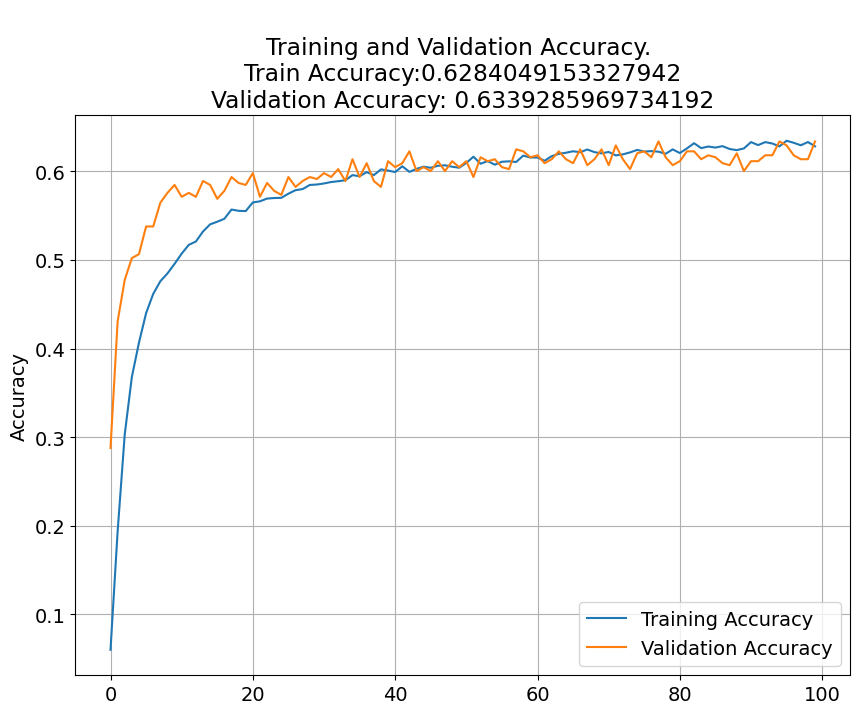

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Store results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot results
# Accuracy
plt.figure(figsize=(10, 16))
plt.rcParams['figure.figsize'] = [16, 9]
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.facecolor'] = 'white'
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title(f'\nTraining and Validation Accuracy. \nTrain Accuracy:{str(acc[-1])}\nValidation Accuracy: {str(val_acc[-1])}')

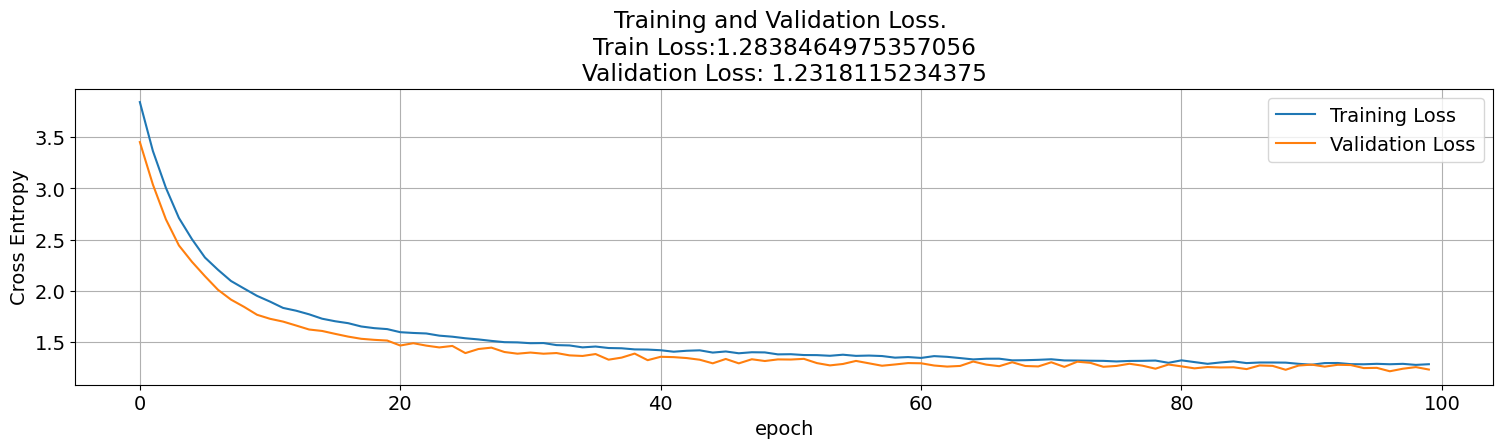

In [13]:
# Loss
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title(f'Training and Validation Loss. \nTrain Loss:{str(loss[-1])}\nValidation Loss: {str(val_loss[-1])}')
plt.xlabel('epoch')
plt.tight_layout(pad=3.0)
plt.show()

In [19]:
# Model evaluation on test data
true_classes = testgen.classes
class_indices = traingen.class_indices
class_indices = dict((v, k) for k, v in class_indices.items())
preds = model.predict(testgen)
pred_classes = np.argmax(preds, axis=1)

2023-04-26 19:03:54.194793: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-04-26 19:03:54.461237: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


50/50 [==============================] - 3s 30ms/step


In [20]:
# Accuracy score
acc_score = accuracy_score(true_classes, pred_classes)
print(f"Inception Model Accuracy without Fine-Tuning: {acc_score * 100:.2f}%")

Inception Model Accuracy without Fine-Tuning: 82.00%


In [21]:
# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(true_classes, pred_classes))


Confusion Matrix:
[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


In [22]:
# Classification report
print("\nClassification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_names))


Classification Report:
                                                                               precision    recall  f1-score   support

             02957_Animalia_Chordata_Amphibia_Anura_Bufonidae_Bufotes_viridis       1.00      1.00      1.00         1
                  02983_Animalia_Chordata_Amphibia_Anura_Hylidae_Hyla_arborea       0.50      1.00      0.67         1
             02992_Animalia_Chordata_Amphibia_Anura_Hylidae_Hyla_meridionalis       0.00      0.00      0.00         1
         03038_Animalia_Chordata_Amphibia_Anura_Ranidae_Pelophylax_ridibundus       0.00      0.00      0.00         1
                  03045_Animalia_Chordata_Amphibia_Anura_Ranidae_Rana_italica       0.50      1.00      0.67         1
               03048_Animalia_Chordata_Amphibia_Anura_Ranidae_Rana_temporaria       0.00      0.00      0.00         1
03097_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Ichthyosaura_alpestris       1.00      1.00      1.00         1
       03100_Animalia_C

Precision: It indicates how many of the samples predicted as a particular class were actually that class. A high precision means there are fewer false positives.

Recall: It indicates how many of the samples belonging to a particular class were correctly predicted by the model. A high recall means there are fewer false negatives.

F1-score: It is the harmonic mean of precision and recall, providing a single metric to evaluate both false positives and false negatives. An F1-score closer to 1 indicates better performance.

Support: It is the number of samples in each class.

The "accuracy" row shows that the overall accuracy of the model is 82%. This means that the model correctly predicted 82% of the samples.

In summary, the model has varying performance across different classes, with some classes having perfect predictions (precision = 1, recall = 1), while others have poor performance. The overall accuracy of the model is 82%, and the average F1-score is around 0.77.

In [19]:
# Fine-tuning: Unfreeze the top layers of the base model
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Re-compile the model with a smaller learning rate for fine-tuning
model.compile(loss='categorical_crossentropy', optimizer=optimizers.Adam(lr=1e-5), metrics=['accuracy'])

# Fit the model again with the fine-tuning
history_finetune = model.fit(traingen,
                             steps_per_epoch=n_steps,
                             validation_data=validgen,
                             validation_steps=n_val_steps,
                             epochs=20,
                             callbacks=[early_stopping, model_checkpoint, reduce_lr_on_plateau])

Epoch 1/20


2023-04-26 04:21:55.650264: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


223/223 [==============================] - ETA: 0s - loss: 1.3636 - accuracy: 0.6110

2023-04-26 04:27:49.534112: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


223/223 [==============================] - 359s 2s/step - loss: 1.3636 - accuracy: 0.6110 - val_loss: 1.2758 - val_accuracy: 0.6116 - lr: 1.0000e-05
Epoch 2/20
223/223 [==============================] - 354s 2s/step - loss: 1.3006 - accuracy: 0.6226 - val_loss: 1.2836 - val_accuracy: 0.6094 - lr: 1.0000e-05
Epoch 3/20
223/223 [==============================] - 353s 2s/step - loss: 1.2946 - accuracy: 0.6270 - val_loss: 1.2744 - val_accuracy: 0.6138 - lr: 1.0000e-05
Epoch 4/20
223/223 [==============================] - 354s 2s/step - loss: 1.3017 - accuracy: 0.6205 - val_loss: 1.1930 - val_accuracy: 0.6317 - lr: 1.0000e-05
Epoch 5/20
223/223 [==============================] - 355s 2s/step - loss: 1.3000 - accuracy: 0.6256 - val_loss: 1.2570 - val_accuracy: 0.6161 - lr: 1.0000e-05
Epoch 6/20
223/223 [==============================] - 352s 2s/step - loss: 1.2841 - accuracy: 0.6298 - val_loss: 1.2410 - val_accuracy: 0.6228 - lr: 1.0000e-05
Epoch 7/20
223/223 [==============================]

In [20]:
# Save model
model.save("model_v2_finetuning.h5")

Text(0.5, 1.0, '\nTraining and Validation Accuracy. \nTrain Accuracy:0.6310727596282959\nValidation Accuracy: 0.6227678656578064')

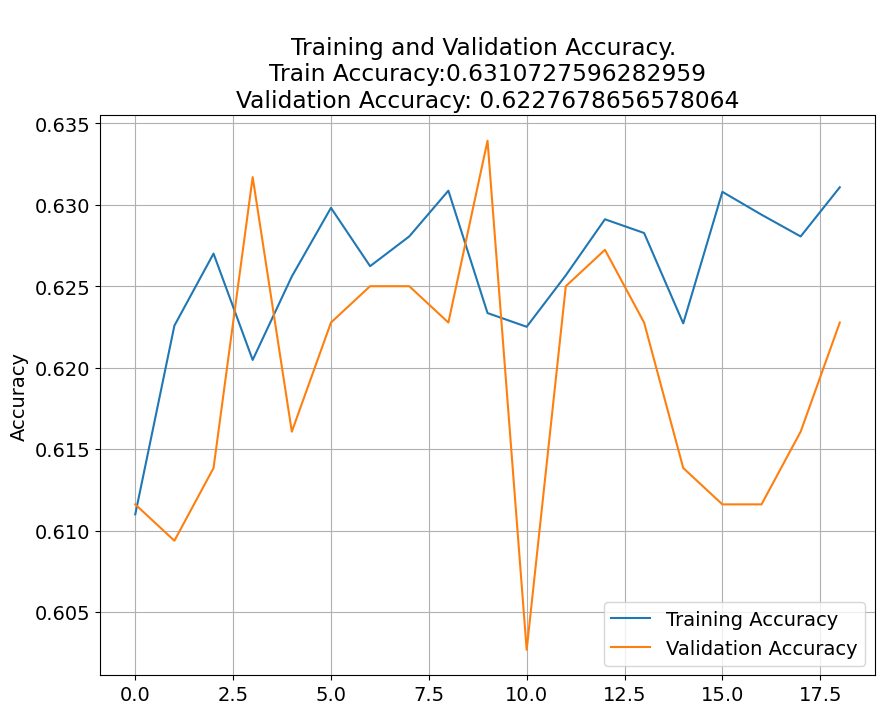

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Store results
acc = history_finetune.history['accuracy']
val_acc = history_finetune.history['val_accuracy']
loss = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']

# Plot results
# Accuracy
plt.figure(figsize=(10, 16))
plt.rcParams['figure.figsize'] = [16, 9]
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.facecolor'] = 'white'
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title(f'\nTraining and Validation Accuracy. \nTrain Accuracy:{str(acc[-1])}\nValidation Accuracy: {str(val_acc[-1])}')

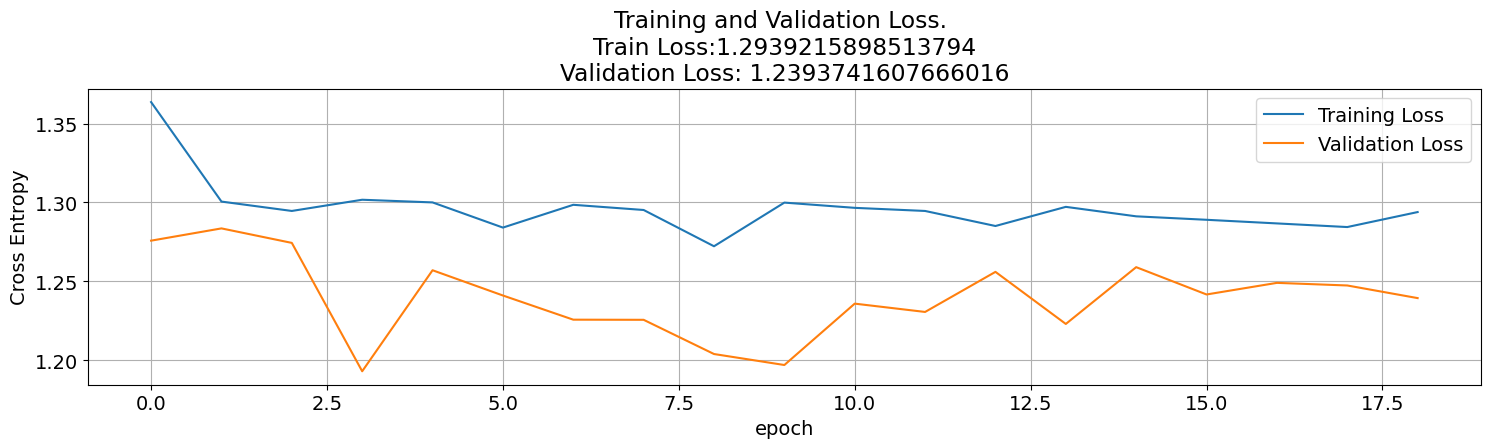

In [22]:
# Loss
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title(f'Training and Validation Loss. \nTrain Loss:{str(loss[-1])}\nValidation Loss: {str(val_loss[-1])}')
plt.xlabel('epoch')
plt.tight_layout(pad=3.0)
plt.show()

In [23]:
# Model evaluation on test data
true_classes = testgen.classes
class_indices = traingen.class_indices
class_indices = dict((v, k) for k, v in class_indices.items())
preds = model.predict(testgen)
pred_classes = np.argmax(preds, axis=1)

50/50 [==============================] - 2s 29ms/step


In [24]:
# Accuracy score
acc_score = accuracy_score(true_classes, pred_classes)
print(f"Inception Model Accuracy without Fine-Tuning: {acc_score * 100:.2f}%")

Inception Model Accuracy without Fine-Tuning: 82.00%


In [25]:
# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(true_classes, pred_classes))


Confusion Matrix:
[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


In [26]:
# Classification report
print("\nClassification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_names))


Classification Report:
                                                                               precision    recall  f1-score   support

             02957_Animalia_Chordata_Amphibia_Anura_Bufonidae_Bufotes_viridis       1.00      1.00      1.00         1
                  02983_Animalia_Chordata_Amphibia_Anura_Hylidae_Hyla_arborea       0.50      1.00      0.67         1
             02992_Animalia_Chordata_Amphibia_Anura_Hylidae_Hyla_meridionalis       0.00      0.00      0.00         1
         03038_Animalia_Chordata_Amphibia_Anura_Ranidae_Pelophylax_ridibundus       0.00      0.00      0.00         1
                  03045_Animalia_Chordata_Amphibia_Anura_Ranidae_Rana_italica       0.50      1.00      0.67         1
               03048_Animalia_Chordata_Amphibia_Anura_Ranidae_Rana_temporaria       0.00      0.00      0.00         1
03097_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Ichthyosaura_alpestris       1.00      1.00      1.00         1
       03100_Animalia_C

In this specific case, the fine-tuning process did not lead to a significant improvement in the model's performance metrics when compared to the non-fine-tuned model. Both models achieved an overall accuracy of 82% and an average F1-score of around 0.77. This suggests that the fine-tuning process, in this instance, was not particularly efficient in enhancing the model's performance. 